In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb 

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_regression #(used for f score, 2pr/p+r)
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")
submission = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")
TARGET = "TargetValue"
ID_COLUMN = "TransactionID"

In [2]:
# loading and helper functions
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.head())
print(train[TARGET].describe())
print((train.isna().mean() * 100).sort_values(ascending=False).head(20))

# no default metric func have to make it oneself 
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# better than replacing by the mode in strings bcz that can be rather more misleading
def safe_str(s):
    return s.where(s.notna(), "__MISSING__").astype(str)

Train shape: (138701, 50)
Test shape: (15000, 49)
   TransactionID  TargetValue  AssetID  ProductConfigID DataOriginCode  \
0        1139309      57000.0   117665               88         ACH138   
1        1139316      26500.0  1001282             4616         ACH138   
2        1139317      21000.0   772709             1948         ACH138   
3        1139322      27000.0   902010             3550         ACH138   
4        1139333      21500.0  1036259            36014         ACH138   

  VendorPartnerID  ManufactureYear  OperationalHoursMeter UtilizationTier  \
0             GTX             1997                 4640.0             Low   
1             GTX             2005                  508.0             Low   
2             GTX             1994                11540.0            High   
3             GTX             2002                 4883.0            High   
4             GTX             2009                  302.0             Low   

  TransactionDate  ...   col20            

In [3]:

# feature engg
def add_basic_features(df):
    df = df.copy()

    date = pd.to_datetime(df["TransactionDate"], errors="coerce")

    df["TransactionYear"] = date.dt.year
    df["TransactionMonth"] = date.dt.month
    df["TransactionQuarter"] = date.dt.quarter
    df["TransactionDayOfYear"] = date.dt.dayofyear
    df["TransactionDateKey"] = date.dt.strftime("%Y-%m-%d").fillna("__MISSING__")
    REFERENCE_DATE = pd.Timestamp("1989-01-01")

    df["TransactionDays"] = (
        date - REFERENCE_DATE
    ).dt.days

    df["ManufactureYear"] = pd.to_numeric(df["ManufactureYear"], errors="coerce")
    df["ManufactureYear"] = df["ManufactureYear"].where(df["ManufactureYear"].between(1900, 2020))

    df["AssetAge"] = df["TransactionYear"] - df["ManufactureYear"]
    df["AssetAge"] = df["AssetAge"].where(df["AssetAge"].between(0, 100))

    df["HasOperationalHours"] = df["OperationalHoursMeter"].notna().astype("int8")

    df["HasVariantModifier"] = (
        df["Spec_VariantModifier"].notna()
        & df["Spec_VariantModifier"].astype(str).str.strip().ne("")
    ).astype("int8")

    df["LogOperationalHours"] = np.log1p(
        pd.to_numeric(df["OperationalHoursMeter"], errors="coerce").clip(lower=0)
    )
    hours = pd.to_numeric(
    df["OperationalHoursMeter"],
    errors="coerce"
    )

    df["HoursPerYear"] = (
        hours / df["AssetAge"].clip(lower=1)
    ).replace([np.inf, -np.inf], np.nan)
    
    functional = df["FunctionalClassification"].fillna("").astype(str)
    
    df["FunctionType"] = (
        functional.str.split(" - ").str[0].replace("", "__MISSING__")
    )

    df["HasAC"] = (
        df["CabinType"].fillna("")
        .astype(str).str.contains("AC", case=False)
        .astype("int8")
    )

    df["HasForks"] = (
        df["Forks"].fillna("")
        .astype(str).str.lower().eq("yes")
        .astype("int8")
    )

    region = df["RegionCode"].fillna("__MISSING__").astype(str)
    inventory = (
        df["InventoryGroupCategory"]
        .fillna("__MISSING__")
        .astype(str)
    )

    df["RegionInventory"] = region + "|" + inventory

    df["YearInventory"] = (
        df["TransactionYear"]
        .fillna(-1).astype(str) + "|" + inventory
    )

    age_filled = df["AssetAge"].fillna(-1)
    df["AssetAgeBin2Cat"] = ((age_filled // 2) * 2).astype("int16").astype(str)
    df["AssetAgeBin5Cat"] = ((age_filled // 5) * 5).astype("int16").astype(str)
    df["ManufactureYearCat"] = df["ManufactureYear"].fillna(-1).astype("int16").astype(str)
    df["TransactionYearCat"] = df["TransactionYear"].fillna(-1).astype("int16").astype(str)
    df["TransactionDay"] = date.dt.day
    df["TransactionDayOfWeek"] = date.dt.dayofweek
    df["TransactionWeek"] = date.dt.isocalendar().week.astype("float32")
    df["ZeroOperationalHours"] = hours.fillna(-1).eq(0).astype("int8")

    full_descriptor = safe_str(df["Spec_FullDescriptor"])
    base_class = safe_str(df["Spec_BaseClass"])
    config = safe_str(df["ProductConfigID"])
    age2 = df["AssetAgeBin2Cat"]
    df["DescriptorLength"] = full_descriptor.str.len().astype("int16")
    df["DescriptorAlpha"] = full_descriptor.str.extract(r"([A-Za-z]+)", expand=False).fillna("__NO_ALPHA__")
    df["DescriptorNumber"] = pd.to_numeric(full_descriptor.str.extract(r"(\d+)", expand=False), errors="coerce")
    df["BaseClassAlpha"] = base_class.str.extract(r"([A-Za-z]+)", expand=False).fillna("__NO_ALPHA__")
    df["ConfigAge2"] = config + "|" + age2
    df["ConfigAge5"] = config + "|" + df["AssetAgeBin5Cat"]
    df["ConfigSaleYear"] = config + "|" + df["TransactionYearCat"]
    df["ConfigRegion"] = config + "|" + region
    df["BaseModelAge2"] = base_class + "|" + age2
    df["FullModelAge2"] = full_descriptor + "|" + age2
    df["FunctionAge2"] = df["FunctionType"].astype(str) + "|" + age2

    specification_cols = [col for col in df.columns if col.startswith("col")]
    df["MissingSpecificationCount"] = df[specification_cols].isna().sum(axis=1).astype("int16")

    df.drop(
        columns=["InventoryGroupDescription"],
        errors="ignore",
        inplace=True
    )

    return df

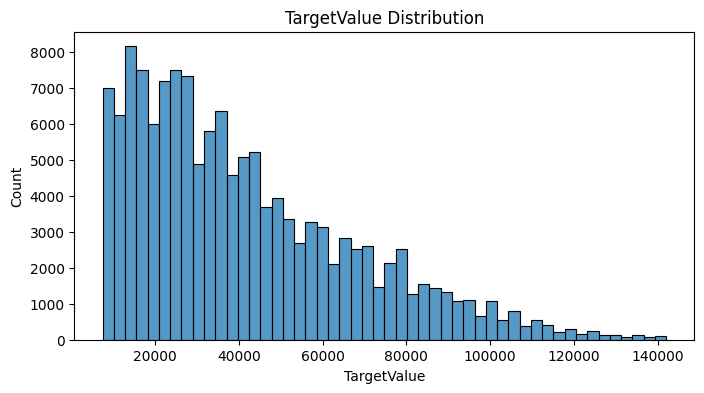

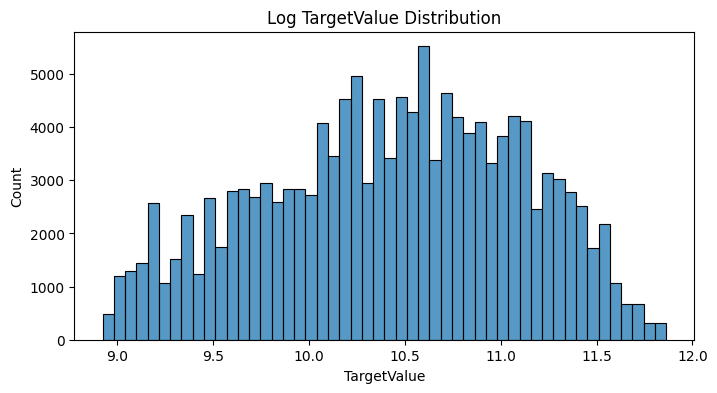

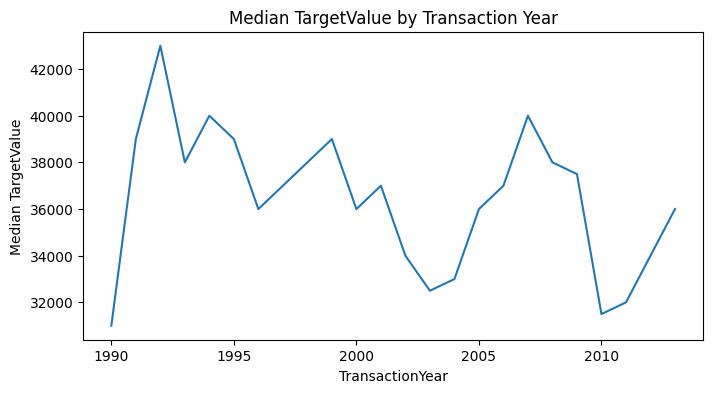

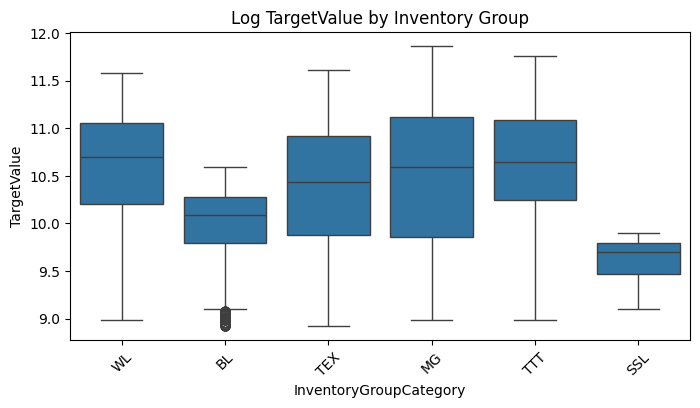

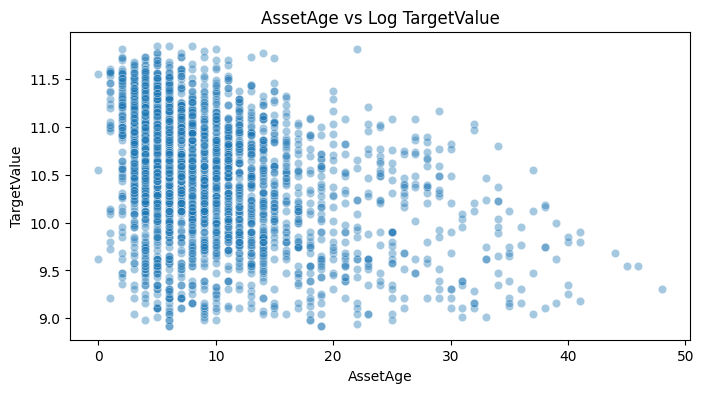

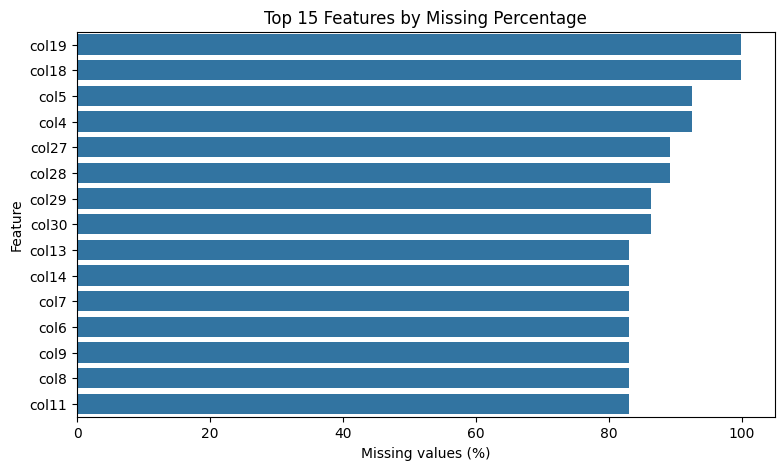

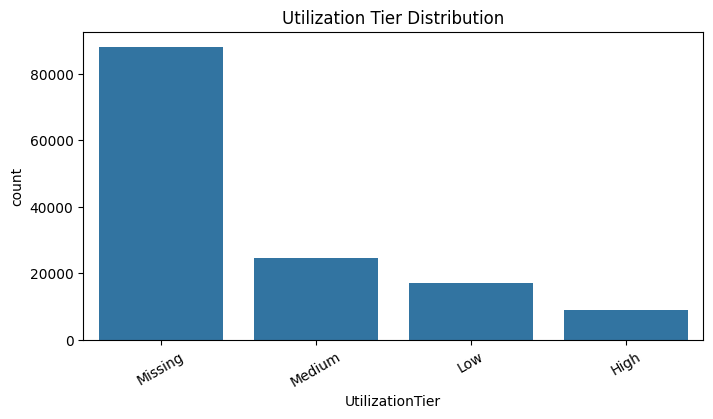

In [4]:
# EDA
train_eda = add_basic_features(train)

#univariate, range of target 
plt.figure(figsize=(8, 4))
sns.histplot(train[TARGET], bins=50)
plt.title("TargetValue Distribution")
plt.show()

#normalise, less tough and costing on values
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(train[TARGET]), bins=50)
plt.title("Log TargetValue Distribution")
plt.show()

#time period data 
plt.figure(figsize=(8, 4))
train_eda.groupby("TransactionYear")[TARGET].median().plot()
plt.title("Median TargetValue by Transaction Year")
plt.ylabel("Median TargetValue")
plt.show()

#diff cat idea
plt.figure(figsize=(8, 4))
top_groups = train_eda["InventoryGroupCategory"].value_counts().head(10).index
sns.boxplot(
    data=train_eda[train_eda["InventoryGroupCategory"].isin(top_groups)],
    x="InventoryGroupCategory",
    y=np.log1p(train_eda.loc[train_eda["InventoryGroupCategory"].isin(top_groups), TARGET])
)
plt.xticks(rotation=45)
plt.title("Log TargetValue by Inventory Group")
plt.show()

#age relation
plt.figure(figsize=(8, 4))
sample_plot = train_eda.sample(min(3000, len(train_eda)), random_state=42)
sns.scatterplot(data=sample_plot, x="AssetAge", y=np.log1p(sample_plot[TARGET]), alpha=0.4)
plt.title("AssetAge vs Log TargetValue")
plt.show()

# which columns have most missing value, 
# will avoid using all those columns they are useless, more of a burden rather than a good metric
missing_pct = train.isna().mean().mul(100).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.title("Top 15 Features by Missing Percentage")
plt.show()

# knowledge about utility, too less
utilization_plot = train[["UtilizationTier"]].copy()
utilization_plot["UtilizationTier"] = utilization_plot["UtilizationTier"].fillna("Missing")

plt.figure(figsize=(8, 4))
sns.countplot(
    data=utilization_plot,
    x="UtilizationTier",
    order=utilization_plot["UtilizationTier"].value_counts().index
)
plt.title("Utilization Tier Distribution")
plt.xticks(rotation=30)
plt.show()

In [5]:
# Configuration
RANDOM_STATE = 42
VALID_SIZE = 0.20
N_FOLDS = 10
SEEDS = [42, 2026, 3407]

expanded_feature_cols = [
    "AssetAgeBin2Cat", "AssetAgeBin5Cat", "ManufactureYearCat",
    "TransactionYearCat", "TransactionDay", "TransactionDayOfWeek",
    "TransactionWeek", "ZeroOperationalHours", "DescriptorLength",
    "DescriptorAlpha", "DescriptorNumber", "BaseClassAlpha",
    "ConfigAge2", "ConfigAge5", "ConfigSaleYear", "ConfigRegion",
    "BaseModelAge2", "FullModelAge2", "FunctionAge2",
    "MissingSpecificationCount"
]

freq_cols = [
    "AssetID",
    "ProductConfigID",
    "Spec_FullDescriptor",
    "Spec_BaseClass",
    "Spec_SubClass",
    "VendorPartnerID",
    "RegionCode",
    "InventoryGroupCategory",
    "InventoryGroupDescription",
    "ConfigAge2",
    "ConfigAge5",
    "ConfigSaleYear",
    "BaseModelAge2",
    "FullModelAge2",
    "DescriptorAlpha"
]

target_encode_cols = [
    "AssetID",
    "ProductConfigID",
    "Spec_FullDescriptor",
    "Spec_BaseClass",
    "Spec_SubClass",
    #"VendorPartnerID",
    "RegionCode",
    #"InventoryGroupCategory",
    #"InventoryGroupDescription"
]

batch_encode_groups = [
    ("ProductDate", ["ProductConfigID", "TransactionDateKey"], 2.0),
    ("ProductYearDate", ["ProductConfigID", "ManufactureYear", "TransactionDateKey"], 1.0),
    ("ProductYearRegionDate", ["ProductConfigID", "ManufactureYear", "RegionCode", "TransactionDateKey"], 1.0)
]

# these cats either increaced the error or the effect minimal or same
# also the rmsle for the validation/training is sometimes being reduced so much 
# like 0.1925 or like even 0.190 compared to what is right now 0.196 ish 
# but actually the final results were being increased with that particular config, so yea

In [6]:
# feature engg helper funcs for the model itself 

#this tells how rare something is, like how many of times it occures
# is it popular ?? ex: this truck was bought from this dealer, 100 times, so this dealer is famous in work
# and this feature may correleate with other factors, like as in why was this dealer called upon always ?
# because his material is good or cheap etc etc.
def add_frequency_features(train_df, test_df, cols):
    train_df = train_df.copy()
    test_df = test_df.copy()

    for col in cols:
        if col not in train_df.columns:
            continue
            
        #overall dataset
        both = pd.concat(
            [
                safe_str(train_df[col]),
                safe_str(test_df[col])
            ],
            axis=0
        )

        #records count of this category of feild 
        counts = both.value_counts(dropna=False)

        # maps each unique record cat with number of times it appears in the column
        train_df[f"{col}_Frequency"] = (
            safe_str(train_df[col])
            .map(counts)
            .astype("float32")
        )

        test_df[f"{col}_Frequency"] = (
            safe_str(test_df[col])
            .map(counts)
            .astype("float32")
        )

    return train_df, test_df

#  avg out the values across record categories 
def add_target_encoding(
    X_train,
    y_train,
    X_valid=None,
    X_test=None,
    cols=None,
    n_splits=10, # match the outer-fold support and reduce encoding noise
    # we will end up leaking the thing
    #did try stratified k-fold that inc the error
    #so we will avg from all other folds and assign to this fold
    random_state=RANDOM_STATE
):
    X_train = X_train.copy()
    X_valid = None if X_valid is None else X_valid.copy()
    X_test = None if X_test is None else X_test.copy()

    global_mean = y_train.mean()

    for col in cols:
        if col not in X_train.columns:
            continue

        new_col = f"{col}_TE"
        X_train[new_col] = np.nan

        train_categories = safe_str(X_train[col])

        inner_kf = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        # create target encoding for x fold from rest 5-x folds for the train data 
        for train_idx, valid_idx in inner_kf.split(X_train):
            category_means = (
                y_train.iloc[train_idx] #kfold index based
                .groupby(train_categories.iloc[train_idx])
                .mean()
            )

            X_train.loc[
                X_train.index[valid_idx],
                new_col
            ] = train_categories.iloc[valid_idx].map(category_means)

        full_category_means = y_train.groupby(train_categories).mean()

        # in case sm new cat and it is emptry, fill with global 
        X_train[new_col] = (
            X_train[new_col]
            .fillna(global_mean)
            .astype("float32")
        )

        #target encode the valid n test thing too 
        if X_valid is not None and col in X_valid.columns:
            X_valid[new_col] = (
                safe_str(X_valid[col])
                .map(full_category_means)
                .fillna(global_mean)
                .astype("float32")
            )

        if X_test is not None and col in X_test.columns:
            X_test[new_col] = (
                safe_str(X_test[col])
                .map(full_category_means)
                .fillna(global_mean)
                .astype("float32")
            )

    return X_train, X_valid, X_test

def add_batch_target_encoding(
    X_train,
    y_train,
    X_valid=None,
    X_test=None,
    groups=None,
    n_splits=10,
    random_state=RANDOM_STATE
):
    X_train = X_train.copy()
    X_valid = None if X_valid is None else X_valid.copy()
    X_test = None if X_test is None else X_test.copy()
    global_mean = float(y_train.mean())

    def encode_from_fit(X_fit, y_fit, X_apply, cols, prior, smoothing):
        fit_keys = pd.DataFrame({col: safe_str(X_fit[col]).to_numpy() for col in cols})
        fit_keys["__target"] = np.asarray(y_fit)
        stats = (
            fit_keys.groupby(cols, sort=False)["__target"]
            .agg(["sum", "count"])
            .reset_index()
        )
        apply_keys = pd.DataFrame({col: safe_str(X_apply[col]).to_numpy() for col in cols})
        mapped = apply_keys.merge(stats, on=cols, how="left", sort=False)
        count = mapped["count"].fillna(0).to_numpy(dtype="float32")
        target_sum = mapped["sum"].fillna(0).to_numpy(dtype="float64")
        encoded = (target_sum + smoothing * prior) / (count + smoothing)
        return encoded.astype("float32"), count

    inner_kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for name, cols, smoothing in groups:
        if not all(col in X_train.columns for col in cols):
            continue
        te_col = f"Batch_{name}_TE"
        count_col = f"Batch_{name}_Count"
        X_train[te_col] = np.nan
        X_train[count_col] = np.nan

        for fit_idx, apply_idx in inner_kf.split(X_train):
            prior = (
                X_train.iloc[apply_idx].get("ProductConfigID_TE", pd.Series(global_mean, index=X_train.index[apply_idx]))
                .fillna(global_mean).to_numpy(dtype="float64")
            )
            encoded, count = encode_from_fit(
                X_train.iloc[fit_idx], y_train.iloc[fit_idx], X_train.iloc[apply_idx],
                cols, prior, smoothing
            )
            X_train.loc[X_train.index[apply_idx], te_col] = encoded
            X_train.loc[X_train.index[apply_idx], count_col] = count

        for frame in [X_valid, X_test]:
            if frame is None:
                continue
            prior = (
                frame.get("ProductConfigID_TE", pd.Series(global_mean, index=frame.index))
                .fillna(global_mean).to_numpy(dtype="float64")
            )
            encoded, count = encode_from_fit(X_train, y_train, frame, cols, prior, smoothing)
            frame[te_col] = encoded
            frame[count_col] = count

        X_train[te_col] = X_train[te_col].fillna(global_mean).astype("float32")
        X_train[count_col] = X_train[count_col].fillna(0).astype("float32")

    return X_train, X_valid, X_test

In [7]:
# prepare model
def make_sklearn_pipeline(X, model, scale_numeric=False):
    numeric_cols = (
        X.select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    categorical_cols = [
        col for col in X.columns
        if col not in numeric_cols
    ]

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    numeric_pipeline = Pipeline(numeric_steps)

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="__MISSING__"
            )
        ),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_cols),
        ("categorical", categorical_pipeline, categorical_cols)
    ])

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

# this is done coz say in a case, train got a,b valid got d and test got e, so ecoding will be wrong 
# a=0,b=1, d=0, e=0
# this is misleading, so weill combine them all and the convert into categorical, so internally codings are correct
# a=0,b=1,d=2,e=3
def make_lgb_categories(
    X_train,
    X_valid=None,
    X_test=None
):
    X_train = X_train.copy()
    X_valid = None if X_valid is None else X_valid.copy()
    X_test = None if X_test is None else X_test.copy()

    categorical_cols = (
        X_train
        .select_dtypes(include=["object", "category"])
        .columns
        .tolist()
    )

    if (
        "ProductConfigID" in X_train.columns
        and "ProductConfigID" not in categorical_cols
    ):
        categorical_cols.append("ProductConfigID")

    frames = [X_train]

    #whole dataset
    if X_valid is not None:
        frames.append(X_valid)

    if X_test is not None:
        frames.append(X_test)

    for col in categorical_cols:
        # DATASET wise, means train valid test as we appended them three 
        all_values = pd.concat(
            [safe_str(frame[col]) for frame in frames],
            axis=0
        ).unique()

        X_train[col] = pd.Categorical(
            safe_str(X_train[col]),
            categories=all_values
        )

        if X_valid is not None:
            X_valid[col] = pd.Categorical(
                safe_str(X_valid[col]),
                categories=all_values
            )

        if X_test is not None:
            X_test[col] = pd.Categorical(
                safe_str(X_test[col]),
                categories=all_values
            )

    return X_train, X_valid, X_test, categorical_cols

In [8]:
train_fe = add_basic_features(train)
test_fe = add_basic_features(test)

for frame in (train_fe, test_fe):
    frame["AssetIDNumeric"] = frame["AssetID"]
    frame["AssetID"] = safe_str(frame["AssetID"])

train_fe, test_fe = add_frequency_features(
    train_fe,
    test_fe,
    freq_cols
)

test_ids = test_fe[ID_COLUMN].copy()

columns_to_drop = [
    TARGET,
    "TransactionDate"
]

X_expanded_base = train_fe.drop(
    columns=columns_to_drop,
    errors="ignore"
)

X_test_expanded_base = test_fe.drop(
    columns=[
        "TransactionDate"
    ],
    errors="ignore"
)

expanded_frequency_cols = [f"{col}_Frequency" for col in freq_cols if col in expanded_feature_cols]
expanded_model_cols = expanded_feature_cols + expanded_frequency_cols
X_base = X_expanded_base.drop(columns=expanded_model_cols, errors="ignore")
X_test_base = X_test_expanded_base.drop(columns=expanded_model_cols, errors="ignore")
X_expanded_only = X_expanded_base.drop(columns=X_base.columns, errors="ignore")
X_test_expanded_only = X_test_expanded_base.drop(columns=X_test_base.columns, errors="ignore")

y_true = train[TARGET]
y_log = np.log1p(y_true)

print("Training shape:", X_base.shape)
print("Test shape:", X_test_base.shape)

Training shape: (138701, 72)
Test shape: (15000, 72)


In [9]:
# if i had a single dataset i would have to had divide into 3 parts
# but since i already have a test dataset different then i can divide train into train and validate
train_indices, valid_indices = train_test_split(
    np.arange(len(X_base)),
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE
)

X_train = X_base.iloc[train_indices].copy()
X_valid = X_base.iloc[valid_indices].copy()

y_train_log = y_log.iloc[train_indices]
#can convert to log too, same thing across errors
y_valid_true = y_true.iloc[valid_indices]

X_train_te, X_valid_te, _ = add_target_encoding(
    X_train,
    y_train_log,
    X_valid=X_valid,
    cols=target_encode_cols
)

X_train_te, X_valid_te, _ = add_batch_target_encoding(
    X_train_te,
    y_train_log,
    X_valid=X_valid_te,
    groups=batch_encode_groups,
    random_state=RANDOM_STATE
)

In [10]:
# nmodel configs
baseline_models = {
    "Ridge Linear Model": make_sklearn_pipeline(
        X_train_te,
        #determines the coeff, regularize them rather to avoid under or over fit
        Ridge(alpha=20),
        scale_numeric=True
    ),

    "Random Forest": make_sklearn_pipeline(
        X_train_te,
        RandomForestRegressor(
            n_estimators=80,
            max_depth=16,
            min_samples_leaf=5, #atleast 5 rows should reach that one rule or pred made
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        scale_numeric=False
    )
}

#configs which will be used later on for the fine tuning instead of base line LGB

base_lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "n_estimators": 10000,
    "learning_rate": 0.02,
    "num_leaves": 63,
    "min_child_samples": 40,
    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.05,
    "reg_lambda": 1.0,
    "cat_smooth": 20,
    "cat_l2": 10,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
    "force_col_wise": True
}

# base_lgb_params = {
#     "objective": "regression",
#     "metric": "rmse",
#     "n_estimators": 8000,
#     "learning_rate": 0.018,
#     "num_leaves": 159,
#     "min_child_samples": 60,
#     "subsample": 0.85,
#     "subsample_freq": 1,
#     "colsample_bytree": 0.85,
#     "reg_alpha": 0.05,
#     "reg_lambda": 3.0,
#     "cat_smooth": 50,
#     "cat_l2": 10,
#     "random_state": 42,
#     "n_jobs": -1,
#     "verbosity": -1,
#     "force_col_wise": True
# }

# base_lgb_params = {
#     "objective": "regression",
#     "metric": "rmse",
#     "n_estimators": 6000,
#     "learning_rate": 0.02,
#     "subsample_freq": 1,
#     "random_state": 42,
#     "n_jobs": -1,
#     "verbosity": -1,
#     "force_col_wise": True
# }

tuning_configs = [
    # Current winner
    # {
    #     "learning_rate": 0.008,
    #     "num_leaves": 1023,
    #     "min_child_samples": 120,
    #     "reg_alpha": 0.12,
    #     "reg_lambda": 10.0,
    #     "path_smooth": 1.0,
    #     "cat_smooth": 120,
    #     "cat_l2": 25,
    #     "max_cat_threshold": 64,
    #     "max_bin": 511,
    # },

    # # Slightly lower path smoothing
    # {
    #     "learning_rate": 0.008,
    #     "num_leaves": 1023,
    #     "min_child_samples": 120,
    #     "reg_alpha": 0.12,
    #     "reg_lambda": 10.0,
    #     "path_smooth": 0.5,
    #     "cat_smooth": 120,
    #     "cat_l2": 25,
    #     "max_cat_threshold": 64,
    #     "max_bin": 511,
    # },

    # # Slightly higher path smoothing
    # {
    #     "learning_rate": 0.008,
    #     "num_leaves": 1023,
    #     "min_child_samples": 120,
    #     "reg_alpha": 0.12,
    #     "reg_lambda": 10.0,
    #     "path_smooth": 1.5,
    #     "cat_smooth": 120,
    #     "cat_l2": 25,
    #     "max_cat_threshold": 64,
    #     "max_bin": 511,
    # },

    # # Softer L1
    # {
    #     "learning_rate": 0.008,
    #     "num_leaves": 1023,
    #     "min_child_samples": 120,
    #     "reg_alpha": 0.08,
    #     "reg_lambda": 10.0,
    #     "path_smooth": 1.0,
    #     "cat_smooth": 120,
    #     "cat_l2": 25,
    #     "max_cat_threshold": 64,
    #     "max_bin": 511,
    # },

    # # Intermediate L2
    # {
    #     "learning_rate": 0.008,
    #     "num_leaves": 1023,
    #     "min_child_samples": 120,
    #     "reg_alpha": 0.12,
    #     "reg_lambda": 8.0,
    #     "path_smooth": 1.0,
    #     "cat_smooth": 120,
    #     "cat_l2": 25,
    #     "max_cat_threshold": 64,
    #     "max_bin": 511,
    # },

    # Slightly more categorical smoothing
    # {
    #     "learning_rate": 0.008,
    #     "num_leaves": 1023,
    #     "min_child_samples": 120,
    #     "reg_alpha": 0.12,
    #     "reg_lambda": 10.0,
    #     "path_smooth": 1.0,
    #     "cat_smooth": 140,
    #     "cat_l2": 30,
    #     "max_cat_threshold": 64,
    #     "max_bin": 511,
    # },
    { "learning_rate": 0.008,
        "num_leaves": 1023,
        "min_child_samples": 120,
        "reg_alpha": 0.12,
        "reg_lambda": 10.0,
        "path_smooth": 1.5,
        "cat_smooth": 140,
        "cat_l2": 30,
        "max_cat_threshold": 64,
        "max_bin": 511,
    },

]

# tuning_configs = [

#     # More capacity, similar regularization
#     {
#         "learning_rate": 0.010,
#         "num_leaves": 767,
#         "min_child_samples": 100,
#         "reg_alpha": 0.10,
#         "reg_lambda": 8.0,
#         "cat_smooth": 100,
#         "cat_l2": 20,
#         "max_cat_threshold": 64,
#         "max_bin": 511,
#     },

#     # 1023 leaves, stronger regularization
#     {
#         "learning_rate": 0.008,
#         "num_leaves": 1023,
#         "min_child_samples": 120,
#         "reg_alpha": 0.15,
#         "reg_lambda": 12.0,
#         "cat_smooth": 120,
#         "cat_l2": 25,
#         "max_cat_threshold": 64,
#         "max_bin": 511,
#     },

#     # 1023 leaves, allow smaller leaves
#     {
#         "learning_rate": 0.008,
#         "num_leaves": 1023,
#         "min_child_samples": 60,
#         "reg_alpha": 0.20,
#         "reg_lambda": 12.0,
#         "min_gain_to_split": 0.01,
    #     "cat_smooth": 80,
    #     "cat_l2": 20,
    #     "max_cat_threshold": 128,
    #     "max_bin": 511,
    # },

    # # Path smoothing
    # {
    #     "learning_rate": 0.009,
    #     "num_leaves": 1023,
    #     "min_child_samples": 80,
    #     "reg_alpha": 0.10,
    #     "reg_lambda": 8.0,
    #     "path_smooth": 10.0,
    #     "cat_smooth": 100,
    #     "cat_l2": 20,
    #     "max_cat_threshold": 128,
    #     "max_bin": 511,
    # },

    # # Less categorical smoothing
    # {
    #     "learning_rate": 0.010,
    #     "num_leaves": 767,
    #     "min_child_samples": 100,
    #     "reg_alpha": 0.10,
    #     "reg_lambda": 8.0,
    #     "cat_smooth": 40,
    #     "cat_l2": 10,
    #     "max_cat_threshold": 256,
    #     "max_bin": 511,
    # },

    # # Aggressive capacity experiment
    # {
    #     "learning_rate": 0.006,
    #     "num_leaves": 1535,
    #     "min_child_samples": 120,
    #     "reg_alpha": 0.25,
    #     "reg_lambda": 15.0,
    #     "min_gain_to_split": 0.005,
    #     "path_smooth": 5.0,
    #     "cat_smooth": 100,
    #     "cat_l2": 25,
    #     "max_cat_threshold": 128,
    #     "max_bin": 1023,
    # },
    #     {
    #     "learning_rate": 0.010,
    #     "num_leaves": 1535,
    #     "min_child_samples": 120,
    #     "reg_alpha": 0.25,
    #     "reg_lambda": 15.0,
    #     "min_gain_to_split": 0.005,
    #     "path_smooth": 5.0,
    #     "cat_smooth": 100,
    #     "cat_l2": 25,
    #     "max_cat_threshold": 128,
    #     "max_bin": 1023,
    # },
    #     {
    #     "learning_rate": 0.012,
    #     "num_leaves": 1535,
    #     "min_child_samples": 120,
    #     "reg_alpha": 0.25,
    #     "reg_lambda": 15.0,
    #     "min_gain_to_split": 0.005,
    #     "path_smooth": 5.0,
    #     "cat_smooth": 100,
    #     "cat_l2": 25,
    #     "max_cat_threshold": 128,
    #     "max_bin": 1023,
    # },

    
    # {
    #     "learning_rate": 0.012,
    #     "num_leaves": 223,
    #     "min_child_samples": 80,
    #     "reg_alpha": 0.05,
    #     "reg_lambda": 5.0,
    #     "cat_smooth": 80,
    #     "cat_l2": 20,
    #     "max_cat_threshold": 64
    # },
    # {
    #     "learning_rate": 0.012,
    #     "num_leaves": 319,
    #     "min_child_samples": 100,
    #     "reg_alpha": 0.10,
    #     "reg_lambda": 7.0,
    #     "cat_smooth": 100,
    #     "cat_l2": 20,
    #     "max_cat_threshold": 64
    # },
    #     {
    #     "learning_rate": 0.010,
    #     "num_leaves": 511,
    #     "min_child_samples": 60,
    #     "reg_alpha": 0.10,
    #     "reg_lambda": 8.0,
    #     "cat_smooth": 60,
    #     "cat_l2": 15,
    #     "max_cat_threshold": 128,
    #     "max_bin": 511,
    
    #     },
    #     {
    #     "learning_rate": 0.012,
    #     "num_leaves": 511,
    #     "min_child_samples": 100,
    #     "reg_alpha": 0.10,
    #     "reg_lambda": 7.0,
    #     "cat_smooth": 100,
    #     "cat_l2": 20,
    #     "max_cat_threshold": 64
    # }

    # {
    #     "learning_rate": 0.012,
    #     "num_leaves": 191,
    #     "min_child_samples": 60,
    #     "reg_alpha": 0.05,
    #     "reg_lambda": 4.0,
    #     "cat_smooth": 60,
    #     "cat_l2": 10,
    #     "max_cat_threshold": 64
    # }


# tuning_configs = [
#     # {
#     #     "learning_rate": 0.02,
#     #     "num_leaves": 127,
#     #     "min_child_samples": 50,
#     #     "reg_lambda": 2.0,
#     #     "cat_smooth": 40
#     # },
#     {
#         "learning_rate": 0.018,
#         "num_leaves": 159,
#         "min_child_samples": 60,
#         "reg_lambda": 3.0,
#         "cat_smooth": 50
#     },
#     {
#         "learning_rate": 0.015,
#         "num_leaves": 191,
#         "min_child_samples": 70,
#         "reg_lambda": 4.0,
#         "cat_smooth": 60,
#     },
#     {
#         "learning_rate": 0.012,
#         "num_leaves": 191,
#         "min_child_samples": 80,
#         "reg_lambda": 5.0,
#         "cat_smooth": 80,
#     },

#     # {
#     #     "learning_rate": 0.025,
#     #     "num_leaves": 95,
#     #     "min_child_samples": 35,
#     #     "reg_lambda": 1.5,
#     #     "cat_smooth": 30
#     # }
# ]



In [11]:
# base line model training- lower to higher and better model

# the other two models here
baseline_results = []

for model_name, model in baseline_models.items():
    model.fit(X_train_te, y_train_log)

    predictions = np.expm1(
        model.predict(X_valid_te)
    )

    score = rmsle(
        y_valid_true,
        predictions
    )

    baseline_results.append({
        "Model": model_name,
        "Validation_RMSLE": score
    })

    print(f"{model_name}: {score:.6f}")

results_df = pd.DataFrame(baseline_results)
results_df.sort_values("Validation_RMSLE")

# LGB from here
X_train_lgb, X_valid_lgb, _, lgb_cat_cols = make_lgb_categories(
    X_train_te,
    X_valid_te
)

lgb_model = lgb.LGBMRegressor(**base_lgb_params)

lgb_model.fit(
    X_train_lgb,
    y_train_log,
    categorical_feature=lgb_cat_cols,
    eval_set=[
        (X_valid_lgb, np.log1p(y_valid_true))
    ],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(150, verbose=False),
        lgb.log_evaluation(200)
    ]
)

lgb_predictions = np.expm1(
    lgb_model.predict(
        X_valid_lgb,
        num_iteration=lgb_model.best_iteration_
    )
)

lgb_score = rmsle(
    y_valid_true,
    lgb_predictions
)

print(f"LightGBM RMSLE: {lgb_score:.6f}")

Ridge Linear Model: 0.274418
Random Forest: 0.217022
[200]	valid_0's rmse: 0.218161
[400]	valid_0's rmse: 0.206134
[600]	valid_0's rmse: 0.202737
[800]	valid_0's rmse: 0.201012
[1000]	valid_0's rmse: 0.20002
[1200]	valid_0's rmse: 0.199345
[1400]	valid_0's rmse: 0.198865
[1600]	valid_0's rmse: 0.19854
[1800]	valid_0's rmse: 0.198272
[2000]	valid_0's rmse: 0.198098
[2200]	valid_0's rmse: 0.197985
[2400]	valid_0's rmse: 0.19791
[2600]	valid_0's rmse: 0.197879
LightGBM RMSLE: 0.197846


,Model,Validation_RMSLE
2,LightGBM,0.197846
1,Random Forest,0.217022
0,Ridge Linear Model,0.274418


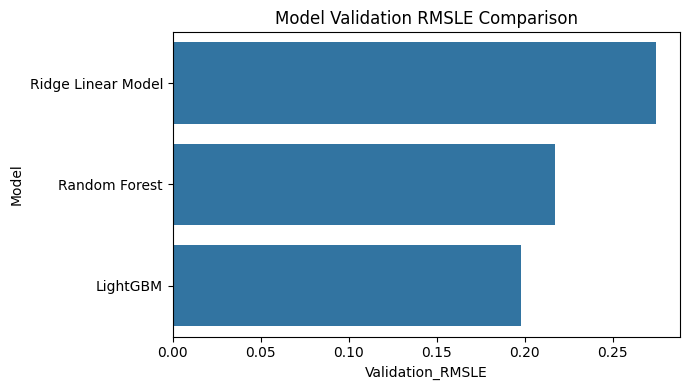

In [12]:
# comparsion of base line models 
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{
            "Model": "LightGBM",
            "Validation_RMSLE": lgb_score
        }])
    ],
    ignore_index=True
)
display(
    results_df.sort_values("Validation_RMSLE")
)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=results_df,
    x="Validation_RMSLE",
    y="Model"
)

plt.title("Model Validation RMSLE Comparison")
plt.tight_layout()
plt.show()

In [13]:
#hyper-param tuning, find the best config

tuning_results = []

for config_number, config in enumerate(tuning_configs, start=1):
    params = {
        **base_lgb_params,
        **config
    }

    tuning_model = lgb.LGBMRegressor(**params)

    tuning_model.fit(
        X_train_lgb,
        y_train_log,
        categorical_feature=lgb_cat_cols,
        eval_set=[
            (X_valid_lgb, np.log1p(y_valid_true))
        ],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(300, verbose=False),
            lgb.log_evaluation(0)
        ]
    )

    predictions = np.expm1(
        tuning_model.predict(
            X_valid_lgb,
            num_iteration=tuning_model.best_iteration_
        )
    )

    score = rmsle(
        y_valid_true,
        predictions
    )

    tuning_results.append({
        "Config_No": config_number,
        "RMSLE": score,
        "Best_Iteration": tuning_model.best_iteration_,
        "Params": config
    })

    print(
        f"Config {config_number}: "
        f"RMSLE={score:.6f}, "
        f"iteration={tuning_model.best_iteration_}"
    )

tuning_results_df = pd.DataFrame(tuning_results)
display(tuning_results_df.sort_values("RMSLE"))

best_row = (
    tuning_results_df
    .sort_values("RMSLE")
    .iloc[0]
)

best_config = best_row["Params"]

final_params = {
    **base_lgb_params,
    **best_config,
    "n_estimators": 10000
}

print("Selected parameters:")
print(best_config)

Config 1: RMSLE=0.192311, iteration=5261


,Config_No,RMSLE,Best_Iteration,Params
0,1,0.192311,5261,"{'learning_rate': 0.008, 'num_leaves': 1023, '..."


Selected parameters:
{'learning_rate': 0.008, 'num_leaves': 1023, 'min_child_samples': 120, 'reg_alpha': 0.12, 'reg_lambda': 10.0, 'path_smooth': 1.5, 'cat_smooth': 140, 'cat_l2': 30, 'max_cat_threshold': 64, 'max_bin': 511}


In [14]:
# MAIN TRAINING CELL

cross_validator = (
    (seed_index, seed, train_idx, valid_idx)
    for seed_index, seed in enumerate(SEEDS)
    for train_idx, valid_idx in KFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=seed
    ).split(X_base)
)

lgb_oof_logs = np.zeros((len(SEEDS), len(X_base)))
lgb_test_logs = np.zeros((len(SEEDS), len(X_test_base)))
expanded_oof_log = np.zeros(len(X_base))
expanded_test_log = np.zeros(len(X_test_base))
auction_oof_log = np.full(len(X_base), np.nan)
auction_test_sum = np.zeros(len(X_test_base))
auction_test_count = np.zeros(len(X_test_base))

best_iterations = []
fold_scores = []
fold_seeds = []
fold_numbers = []
fold_importances = []

for model_number, (seed_index, seed, train_idx, valid_idx) in enumerate(
    cross_validator,
    start=1
):
    fold = (model_number - 1) % N_FOLDS + 1
    print(f"\nTraining seed {seed}, fold {fold}/{N_FOLDS}")

    X_train_fold = X_base.iloc[train_idx].copy()
    X_valid_fold = X_base.iloc[valid_idx].copy()

    y_train_fold = y_log.iloc[train_idx]
    y_valid_fold_log = y_log.iloc[valid_idx]
    y_valid_fold_true = y_true.iloc[valid_idx]

    X_train_fold, X_valid_fold, X_test_fold = add_target_encoding(
        X_train_fold,
        y_train_fold,
        X_valid=X_valid_fold,
        X_test=X_test_base,
        cols=target_encode_cols,
        random_state=seed
    )

    X_train_fold, X_valid_fold, X_test_fold = add_batch_target_encoding(
        X_train_fold,
        y_train_fold,
        X_valid=X_valid_fold,
        X_test=X_test_fold,
        groups=batch_encode_groups,
        random_state=seed
    )

    if seed_index == 0:
        X_train_expanded = pd.concat([X_train_fold, X_expanded_only.iloc[train_idx]], axis=1)
        X_valid_expanded = pd.concat([X_valid_fold, X_expanded_only.iloc[valid_idx]], axis=1)
        X_test_expanded = pd.concat([X_test_fold, X_test_expanded_only], axis=1)

        for frame, output_index, is_test in [
            (X_valid_fold, valid_idx, False),
            (X_test_fold, None, True),
        ]:
            count = frame["Batch_ProductYearRegionDate_Count"].to_numpy()
            encoded = frame["Batch_ProductYearRegionDate_TE"].to_numpy()
            prior = frame["ProductConfigID_TE"].to_numpy()
            mask = count > 0
            raw_mean = np.full(len(frame), np.nan)
            raw_mean[mask] = ((count[mask] + 1.0) * encoded[mask] - prior[mask]) / count[mask]
            if is_test:
                auction_test_sum[mask] += raw_mean[mask]
                auction_test_count[mask] += 1
            else:
                auction_oof_log[output_index] = raw_mean

    X_train_fold, X_valid_fold, X_test_fold, fold_cat_cols = (
        make_lgb_categories(
            X_train_fold,
            X_valid_fold,
            X_test_fold
        )
    )

    fold_params = {
        **final_params,
        "random_state": seed,
        "bagging_seed": seed,
        "feature_fraction_seed": seed,
        "data_random_seed": seed
    }
    fold_model = lgb.LGBMRegressor(**fold_params)

    fold_model.fit(
        X_train_fold,
        y_train_fold,
        categorical_feature=fold_cat_cols,
        eval_set=[
            (
                X_valid_fold,
                y_valid_fold_log
            )
        ],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(
                300,
                verbose=False
            ),
            lgb.log_evaluation(200)
        ]
    )

    fold_valid_log = fold_model.predict(
        X_valid_fold,
        num_iteration=fold_model.best_iteration_
    )

    fold_test_log = fold_model.predict(
        X_test_fold,
        num_iteration=fold_model.best_iteration_
    )

    if seed_index == 0:
        X_train_expanded, X_valid_expanded, X_test_expanded, expanded_cat_cols = make_lgb_categories(
            X_train_expanded, X_valid_expanded, X_test_expanded
        )
        expanded_model = lgb.LGBMRegressor(**fold_params)
        expanded_model.fit(
            X_train_expanded, y_train_fold,
            categorical_feature=expanded_cat_cols,
            eval_set=[(X_valid_expanded, y_valid_fold_log)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(300, verbose=False), lgb.log_evaluation(0)]
        )
        expanded_oof_log[valid_idx] = expanded_model.predict(
            X_valid_expanded, num_iteration=expanded_model.best_iteration_
        )
        expanded_test_log += expanded_model.predict(
            X_test_expanded, num_iteration=expanded_model.best_iteration_
        ) / N_FOLDS

    lgb_oof_logs[seed_index, valid_idx] = fold_valid_log
    lgb_test_logs[seed_index] += fold_test_log / N_FOLDS

    fold_predictions = np.expm1(fold_valid_log)
    fold_predictions = np.clip(
        fold_predictions,
        0,
        None
    )

    fold_score = rmsle(
        y_valid_fold_true,
        fold_predictions
    )

    fold_scores.append(fold_score)
    fold_seeds.append(seed)
    fold_numbers.append(fold)
    best_iterations.append(
        fold_model.best_iteration_
    )

    fold_importances.append(
        pd.Series(
            fold_model.feature_importances_,
            index=fold_model.feature_name_
        )
    )

    print(
        f"Seed {seed}, fold {fold} RMSLE: "
        f"{fold_score:.6f}"
    )

# RMSLE is RMSE in log1p space, so mean the OOFs before expm1.
base_oof_log = lgb_oof_logs.mean(axis=0)
base_test_log = lgb_test_logs.mean(axis=0)
lgb_oof_log = 0.65 * base_oof_log + 0.35 * expanded_oof_log
lgb_test_log = 0.65 * base_test_log + 0.35 * expanded_test_log

auction_mask = ~np.isnan(auction_oof_log)
lgb_oof_log[auction_mask] = 0.75 * lgb_oof_log[auction_mask] + 0.25 * auction_oof_log[auction_mask]
test_auction_mask = auction_test_count > 0
auction_test_log = np.divide(auction_test_sum, auction_test_count, out=np.zeros_like(auction_test_sum), where=test_auction_mask)
lgb_test_log[test_auction_mask] = 0.75 * lgb_test_log[test_auction_mask] + 0.25 * auction_test_log[test_auction_mask]
valid_predictions = np.expm1(lgb_oof_log)
test_predictions = np.expm1(lgb_test_log)

valid_predictions = np.clip(
    valid_predictions,
    0,
    None
)

test_predictions = np.clip(
    test_predictions,
    0,
    None
)


Training seed 42, fold 1/10
[200]	valid_0's rmse: 0.26302
[400]	valid_0's rmse: 0.214892
[600]	valid_0's rmse: 0.204396
[800]	valid_0's rmse: 0.20001
[1000]	valid_0's rmse: 0.197474
[1200]	valid_0's rmse: 0.195807
[1400]	valid_0's rmse: 0.194625
[1600]	valid_0's rmse: 0.193748
[1800]	valid_0's rmse: 0.193095
[2000]	valid_0's rmse: 0.192598
[2200]	valid_0's rmse: 0.192244
[2400]	valid_0's rmse: 0.191911
[2600]	valid_0's rmse: 0.191645
[2800]	valid_0's rmse: 0.191442
[3000]	valid_0's rmse: 0.191296
[3200]	valid_0's rmse: 0.191172
[3400]	valid_0's rmse: 0.19105
[3600]	valid_0's rmse: 0.190962
[3800]	valid_0's rmse: 0.190886
[4000]	valid_0's rmse: 0.190811
[4200]	valid_0's rmse: 0.190765
[4400]	valid_0's rmse: 0.190748
[4600]	valid_0's rmse: 0.190725
[4800]	valid_0's rmse: 0.190723
[5000]	valid_0's rmse: 0.190706
[5200]	valid_0's rmse: 0.190707
[5400]	valid_0's rmse: 0.190703
[5600]	valid_0's rmse: 0.190724
Seed 42, fold 1 RMSLE: 0.190692

Training seed 42, fold 2/10
[200]	valid_0's rmse:

,Seed,Fold,RMSLE,Best_Iteration
0,42,1,0.190692,5306
1,42,2,0.189016,4455
2,42,3,0.192332,5556
3,42,4,0.190050,5438
4,42,5,0.193118,4892
5,42,6,0.195483,4402
6,42,7,0.195460,5213
7,42,8,0.192769,4678
8,42,9,0.192274,5598
9,42,10,0.191327,4908


,Seed,OOF_RMSLE
0,42,0.192263
1,2026,0.192236
2,3407,0.192336


Mean fold RMSLE: 0.192267
Multi-seed mean OOF RMSLE: 0.189570
Average best iteration: 5003


,Feature,Importance
0,AssetIDNumeric,282288.933333
1,TransactionDayOfYear,243839.200000
2,RegionCode_TE,199813.466667
3,TransactionDays,190733.266667
4,AssetAge,188256.766667
5,Batch_ProductDate_TE,177700.333333
6,ManufactureYear,174989.466667
7,Spec_BaseClass_TE,166928.900000
8,Spec_SubClass_TE,161527.266667
9,TransactionID,159709.533333


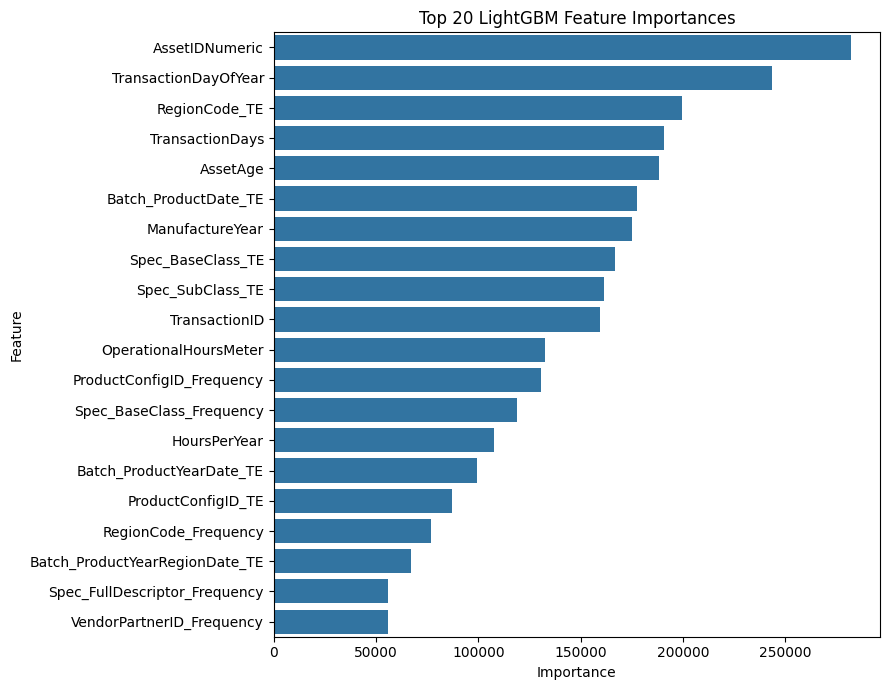

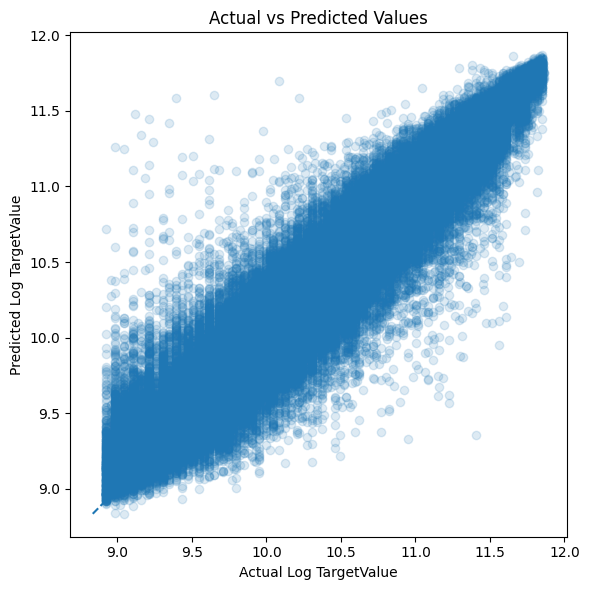

,TargetValue,InventoryGroupCategory,UtilizationTier,TransactionYear,HasOperationalHours,Prediction,AbsoluteLogError
41946,9100.0,TTT,NaN,2000,0,96916.797120,2.365479
30470,8000.0,TEX,NaN,2008,0,77487.158648,2.270559
21266,10000.0,TEX,NaN,2005,0,93611.307669,2.236477
79081,8500.0,WL,NaN,2010,1,76660.704632,2.199218
30067,12000.0,TEX,NaN,2000,0,107351.232321,2.191125
37385,9500.0,WL,NaN,2000,0,84182.549376,2.181602
71328,11500.0,TEX,Medium,1996,1,90910.518843,2.067453
60154,10300.0,TEX,NaN,2002,0,80538.530158,2.056507
114093,90000.0,TEX,NaN,2012,1,11565.413500,2.051715
5722,9000.0,WL,NaN,2008,1,66783.452731,2.004135


In [15]:
#POST TRAINING ANALYSIS CELL, performance error etc.

#cross validation summary 
valid_predictions = np.clip(
    valid_predictions,
    0,
    None
)

test_predictions = np.clip(
    test_predictions,
    0,
    None
)

fold_results = pd.DataFrame({
    "Seed": fold_seeds,
    "Fold": fold_numbers,
    "RMSLE": fold_scores,
    "Best_Iteration": best_iterations
})

seed_results = pd.DataFrame({
    "Seed": SEEDS,
    "OOF_RMSLE": [
        rmsle(y_true, np.clip(np.expm1(seed_oof), 0, None))
        for seed_oof in lgb_oof_logs
    ]
})

cv_score = rmsle(
    y_true,
    valid_predictions
)

display(fold_results)
display(seed_results)

print(f"Mean fold RMSLE: {np.mean(fold_scores):.6f}")
print(f"Multi-seed mean OOF RMSLE: {cv_score:.6f}")
print(f"Average best iteration: {int(np.mean(best_iterations))}")

#feature importance analysis
importance_df = (
    pd.concat(fold_importances, axis=1)
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(20)
    .rename_axis("Feature")
    .reset_index(name="Importance")
)

display(importance_df)

plt.figure(figsize=(9, 7))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 LightGBM Feature Importances")
plt.tight_layout()
plt.show()

#acvtual vs predicted 
actual_log = np.log1p(y_true)
predicted_log = np.log1p(valid_predictions)

minimum = min(
    actual_log.min(),
    predicted_log.min()
)

maximum = max(
    actual_log.max(),
    predicted_log.max()
)

plt.figure(figsize=(6, 6))

plt.scatter(
    actual_log,
    predicted_log,
    alpha=0.15
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Log TargetValue")
plt.ylabel("Predicted Log TargetValue")
plt.title("Actual vs Predicted Values")
plt.tight_layout()
plt.show()

# ERRORS 
analysis_columns = [
    TARGET,
    "InventoryGroupCategory",
    "UtilizationTier",
    "TransactionYear",
    "HasOperationalHours"
]

available_analysis_columns = [
    col for col in analysis_columns
    if col in train_fe.columns
]

error_df = train_fe[
    available_analysis_columns
].copy()

error_df["Prediction"] = valid_predictions

error_df["AbsoluteLogError"] = np.abs(
    np.log1p(error_df[TARGET]) -
    np.log1p(error_df["Prediction"])
)

worst_predictions = (
    error_df
    .sort_values(
        "AbsoluteLogError",
        ascending=False
    )
    .head(10)
)

display(worst_predictions)


In [16]:
submission[ID_COLUMN] = test_ids
submission[TARGET] = test_predictions

submission.to_csv(
    "submission.csv",
    index=False
)

print("Created submission.csv")
display(submission.head())

Created submission.csv


,TransactionID,TargetValue
0,1139307,63650.180873
1,1139419,79385.021049
2,1139482,31529.397289
3,1139522,21348.395126
4,1139684,13782.836187


# MILESTONE-1

In [17]:
print(train.shape,test.shape)

(138701, 50) (15000, 49)


In [18]:
set(train.columns)-set(test.columns)

{'TargetValue'}

In [19]:
cols=train.select_dtypes(include='number').columns
len(cols)


6

In [20]:
missing=train.isna().sum()
missing[missing > 124800]

col4     128320
col5     128320
col18    138635
col19    138635
dtype: int64

In [21]:
train['OperationalHoursMeter'].isna().mean()*100

np.float64(40.838205924975306)

In [22]:
train['TargetValue'].median()

35000.0

In [23]:
train['ManufactureYear'].mode()[0]

np.int64(1001)

In [24]:
train['TransactionDate']=pd.to_datetime(train['TransactionDate'])
train['TransactionDate'].min()

Timestamp('1990-01-31 00:00:00')

In [25]:
train['Spec_BaseClass'].nunique()

1249

In [26]:
train['RegionCode'].value_counts().head()

RegionCode
Florida       23460
Texas         18284
California     9525
Washington     6063
Georgia        5240
Name: count, dtype: int64

In [27]:
train[train['RegionCode']=='Florida']['TargetValue'].mean()

np.float64(45007.54262574595)

In [28]:
train['UtilizationTier'].value_counts(dropna=False)

UtilizationTier
NaN       88226
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64

In [29]:
train[['TargetValue','OperationalHoursMeter']].corr()

,TargetValue,OperationalHoursMeter
TargetValue,1.000000,0.001994
OperationalHoursMeter,0.001994,1.000000


In [30]:
train['FunctionalClassification'].value_counts().head()

FunctionalClassification
Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons      11158
Motorgrader - 145.0 to 170.0 Horsepower                     8107
Hydraulic Excavator, Track - 12.0 to 14.0 Metric Tons       7625
Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth     7603
Hydraulic Excavator, Track - 33.0 to 40.0 Metric Tons       7440
Name: count, dtype: int64

# MILESTONE-2

In [31]:
train["TransactionDate"]=pd.to_datetime(train["TransactionDate"], errors="coerce")
train["TransactionYear"]=train["TransactionDate"].dt.year
train["TransactionQuarter"]=train["TransactionDate"].dt.quarter

train["AssetAge"]=train["TransactionYear"] - train["ManufactureYear"]

train["DescriptorLength"]=train["Spec_FullDescriptor"].fillna("").str.len()

train["HasOperationalHours"]=train["OperationalHoursMeter"].notna().astype(int)

train["HasVariantModifier"]=train["Spec_VariantModifier"].notna().astype(int)

In [32]:
train["AssetAge"].mode()[0]

np.int64(5)

In [33]:
train.groupby("TransactionQuarter")["TargetValue"].mean().sort_values(ascending=False)

TransactionQuarter
1    42873.587453
2    41408.258228
3    40619.200589
4    40562.454024
Name: TargetValue, dtype: float64

In [34]:
train["DescriptorLength"].max()

19

In [35]:
train["HasOperationalHours"].sum()

np.int64(82058)

In [36]:
train["HasVariantModifier"].mean()*100

np.float64(37.730081253920304)

In [37]:
train["ManufactureYear"].mean()

np.float64(1891.640853346407)

In [38]:
encoded = pd.get_dummies(
    train[["RegionCode","CabinType","UtilizationTier"]],
    drop_first=True
)

encoded.shape

(138701, 56)

In [39]:
corr=train.select_dtypes(include="number").corr()
corr["TargetValue"].abs().sort_values(ascending=False)

TargetValue              1.000000
AssetID                  0.238719
HasVariantModifier       0.217434
AssetAge                 0.204698
ManufactureYear          0.204439
DescriptorLength         0.061502
ProductConfigID          0.057265
TransactionQuarter       0.034442
TransactionYear          0.024497
TransactionID            0.012093
HasOperationalHours      0.009653
OperationalHoursMeter    0.001994
Name: TargetValue, dtype: float64

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

num_cols=["ManufactureYear","OperationalHoursMeter","AssetAge"]

for col in num_cols:
    train[col]=train[col].fillna(train[col].mean())

scaler=StandardScaler()
train[num_cols]=scaler.fit_transform(train[num_cols])

X= train.drop(columns=["TargetValue"])
y= train["TargetValue"]

X_train,X_val,y_train,y_val= train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_val.shape)

(110960, 55)
(27741, 55)


In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

features = ["ManufactureYear","AssetAge"]

model= LinearRegression()
model.fit(X_train[features], y_train)

val_preds= model.predict(X_val[features])

r2 = r2_score(y_val, val_preds)
print(r2)

0.04182681098431851


# MILESTONE 3

In [42]:
train["CabinType"].fillna("Missing").eq("Missing").sum()

np.int64(0)

In [43]:
train["OperationalHoursMeter"].median()

0.0

In [44]:
train["SaleYear"] = pd.to_datetime(train["TransactionDate"], errors="coerce").dt.year

manufacture_year = pd.to_numeric(train["ManufactureYear"], errors="coerce")
manufacture_year = manufacture_year.replace([1000, 1001], np.nan)

train["AssetAge"] = train["SaleYear"] - manufacture_year

train["AssetAge"].median()


2008.6698301204876

In [45]:
train["HoursPerYear"]= train["OperationalHoursMeter"]/train["AssetAge"]
train["HoursPerYear"].replace([np.inf, -np.inf], np.nan).dropna().median()

0.0

In [46]:
missing_rate=train.isna().mean()
missing_rate[missing_rate>0.80]

col4     0.925156
col5     0.925156
col6     0.831256
col7     0.831256
col8     0.831256
col9     0.831256
col11    0.831256
col13    0.831256
col14    0.831256
col18    0.999524
col19    0.999524
col27    0.892149
col28    0.892149
col29    0.863938
col30    0.863938
dtype: float64

In [47]:
train["SaleYear"].mode()[0]

np.int32(2010)

In [48]:
log_target=np.log1p(train[TARGET])
log_target.std()

0.6709620692098283

In [49]:
X= train.drop(columns=["TargetValue"])
y= train["TargetValue"]

X_train,X_valid,y_train,y_valid =train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape

(110960, 57)

# MILESTONE 4


In [50]:
# train["UtilizationTier"] = train["UtilizationTier"].fillna("Unknown")
# train["PriceBand"] = pd.qcut(train["TargetValue"], q=5, labels=False)

# X = train.drop(columns="TargetValue")
# y = train["TargetValue"]

# X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, stratify=X["PriceBand"]
# )

# train_counts = X_train["PriceBand"].value_counts().sort_index().to_numpy()
# valid_counts = X_valid["PriceBand"].value_counts().sort_index().to_numpy()

# _, X_valid_ns, _, _ = train_test_split(
#     X, y, test_size=0.3, random_state=42, stratify=None
# )

# valid_counts_ns = X_valid_ns["PriceBand"].value_counts().sort_index().to_numpy()

# result_q1 = np.max(
#     np.abs(valid_counts / valid_counts.sum() - valid_counts_ns / valid_counts_ns.sum())
# )

# print(train_counts)
# print(valid_counts)
# print(valid_counts_ns)
# print(round(result_q1, 4))

In [51]:
# cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"]
# num_cols = ["ManufactureYear", "OperationalHoursMeter"]

# cat_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
# ])

# num_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="mean")),
#     ("scaler", StandardScaler())
# ])

# preprocessor = ColumnTransformer([
#     ("cat", cat_pipe, cat_cols),
#     ("num", num_pipe, num_cols)
# ], remainder="drop")

# X_train_proc = preprocessor.fit_transform(X_train)
# X_valid_proc = preprocessor.transform(X_valid)

# print(round(float(X_train_proc.sum()), 3))

In [52]:
# from sklearn.model_selection import RandomizedSearchCV

# search = RandomizedSearchCV(
#     RandomForestRegressor(random_state=42),
#     {
#         "n_estimators": [50, 100, 200],
#         "max_depth": [5, 10, 15]
#     },
#     n_iter=5,
#     cv=3,
#     random_state=42,
#     n_jobs=-1
# )

# search.fit(X_train_proc, y_train)
# print(search.best_params_["n_estimators"])

In [53]:
# from sklearn.ensemble import AdaBoostRegressor

# ada = AdaBoostRegressor(n_estimators=50, random_state=42)
# ada.fit(X_train_proc, y_train)

# print(round(np.var(ada.estimator_errors_), 4))

In [54]:
# rf = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     random_state=42
# )

# rf.fit(X_train_proc, y_train)
# print(np.argmax(rf.feature_importances_))

In [55]:
# N = X_train_proc.shape[1]
# weights = N * 128 + 128 * 64 + 64 * 32 + 32
# print(weights)

In [56]:
# from sklearn.neural_network import MLPRegressor

# mlp = MLPRegressor(
#     hidden_layer_sizes=(128, 64, 32),
#     activation="relu",
#     solver="adam",
#     max_iter=5,
#     batch_size=32,
#     random_state=42
# )

# mlp.fit(X_train_proc, y_train)
# print(round(mlp.loss_, 4))

In [57]:
# from sklearn.metrics import mean_absolute_error

# mlp_a = MLPRegressor(
#     hidden_layer_sizes=(100,),
#     alpha=0.0001,
#     max_iter=5,
#     random_state=42
# )

# mlp_b = MLPRegressor(
#     hidden_layer_sizes=(100,),
#     alpha=1.0,
#     max_iter=5,
#     random_state=42
# )

# mlp_a.fit(X_train_proc, y_train)
# mlp_b.fit(X_train_proc, y_train)

# mae_a = mean_absolute_error(y_train, mlp_a.predict(X_train_proc))
# mae_b = mean_absolute_error(y_train, mlp_b.predict(X_train_proc))

# print(round(abs(mae_a - mae_b), 4))

In [58]:
# valid_pred = mlp.predict(X_valid_proc)
# valid_mae = mean_absolute_error(y_valid, valid_pred)
# print(round(valid_mae, 4))

# MILESTONE 5

In [59]:
train["ManufactureDecade"] = (train["ManufactureYear"] // 10) * 10
train.groupby("ManufactureDecade")["TargetValue"].mean().idxmax()

np.float64(0.0)

In [60]:
train["SpecificationComplexity"] = train["Spec_FullDescriptor"].fillna("").str.split().str.len()
train["SpecificationComplexity"].max()

4

In [61]:
cat = [
    "DataOriginCode", "VendorPartnerID", "UtilizationTier",
    "AssetScaleFactor", "RegionCode",
    "InventoryGroupCategory", "InventoryGroupDescription"
]

num = train.select_dtypes(include=np.number).columns.difference(
    ["TargetValue", "TransactionID", "AssetID"] + cat
).tolist()

X = train[cat + num]
y = train["TargetValue"]
X.shape[1]

20

In [62]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=.2, random_state=42
)
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat)
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_train_p.shape

(110960, 123)

In [63]:
selector = SelectKBest(f_regression, k=100)
X_train_s = selector.fit_transform(X_train_p, y_train)
X_val_s = selector.transform(X_val_p)

names = preprocessor.get_feature_names_out()
scores = pd.Series(selector.scores_, index=names)
selected = scores[selector.get_support()]

In [64]:
selected.idxmax()

'cat__AssetScaleFactor_Mini'

In [65]:
selected.idxmin()

'cat__RegionCode_Puerto Rico'

In [66]:
scores[~selector.get_support()].index.tolist()

['num__HoursPerYear',
 'num__OperationalHoursMeter',
 'cat__DataOriginCode_ADI149',
 'cat__VendorPartnerID_AFZ',
 'cat__VendorPartnerID_CBS',
 'cat__VendorPartnerID_RGK',
 'cat__VendorPartnerID_RKC',
 'cat__VendorPartnerID_RZI',
 'cat__VendorPartnerID_SGU',
 'cat__VendorPartnerID_TAI',
 'cat__RegionCode_Arkansas',
 'cat__RegionCode_Delaware',
 'cat__RegionCode_Iowa',
 'cat__RegionCode_Kentucky',
 'cat__RegionCode_Montana',
 'cat__RegionCode_Nebraska',
 'cat__RegionCode_New Jersey',
 'cat__RegionCode_Oklahoma',
 'cat__RegionCode_Rhode Island',
 'cat__RegionCode_Tennessee',
 'cat__RegionCode_Utah',
 'cat__RegionCode_Vermont',
 'cat__RegionCode_Washington DC']

In [67]:
# rf = RandomForestRegressor(random_state=42, n_jobs=-1)
# rf.fit(X_train_s, y_train)
# pred = rf.predict(X_val_s)

In [68]:
#np.floor(mean_absolute_error(y_val, pred) * 100) / 100

In [69]:
#np.floor(mean_squared_error(y_val, pred) ** .5 * 100) / 100

In [70]:
# search = RandomizedSearchCV(
#     RandomForestRegressor(random_state=42, n_jobs=-1),
#     {
#         "n_estimators": [100, 200],
#         "max_features": ["sqrt"]
#     },
#     n_iter=4,
#     cv=3,
#     scoring="neg_root_mean_squared_error",
#     random_state=42,
#     n_jobs=-1
# )

# search.fit(X_train_s, y_train)
# best_pred = search.best_estimator_.predict(X_val_s)

In [71]:
#search.best_params_["n_estimators"]

In [72]:
#print(search.best_params_["max_depth"])

In [73]:
#np.floor(-search.best_score_ * 100) / 100

In [74]:
#np.floor(mean_absolute_error(y_val, best_pred) * 100) / 100

In [75]:
#np.floor(mean_squared_error(y_val, best_pred) ** .5 * 100) / 100